In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/train.csv")

print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

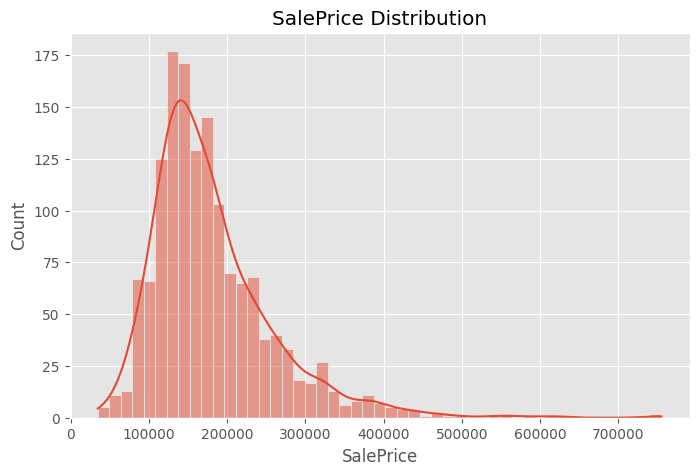

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("SalePrice Distribution")
plt.show()

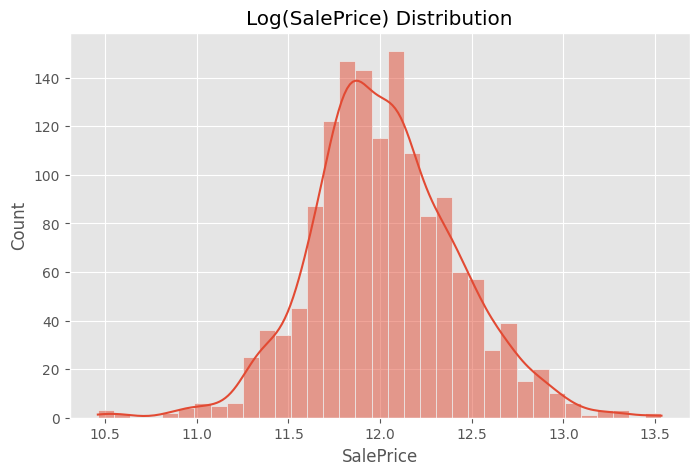

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["SalePrice"]), kde=True)
plt.title("Log(SalePrice) Distribution")
plt.show()

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Ratio (%)": missing_ratio
})

missing_df[missing_df["Missing Count"] > 0].head(15)

,Missing Count,Missing Ratio (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


In [7]:
print("""
Insight:
- PoolQC / MiscFeature / Alley 缺失比例極高 → 幾乎代表 "No feature"
- Garage / Basement 缺失 → 通常代表沒有該設施
- LotFrontage → 需要 neighborhood level imputation
""")


Insight:
- PoolQC / MiscFeature / Alley 缺失比例極高 → 幾乎代表 "No feature"
- Garage / Basement 缺失 → 通常代表沒有該設施
- LotFrontage → 需要 neighborhood level imputation



In [8]:
num_df = df.select_dtypes(include=[np.number])

corr = num_df.corr()["SalePrice"].sort_values(ascending=False)

top_corr = corr[1:11]
top_corr

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

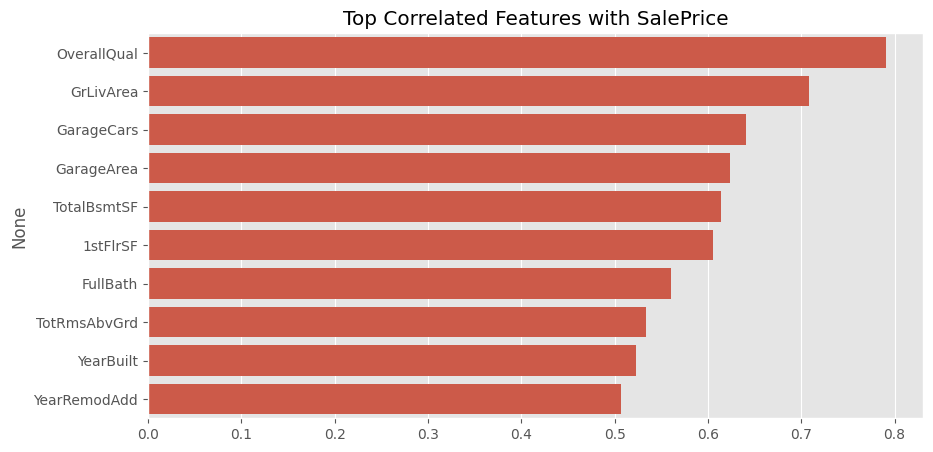

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top Correlated Features with SalePrice")
plt.show()

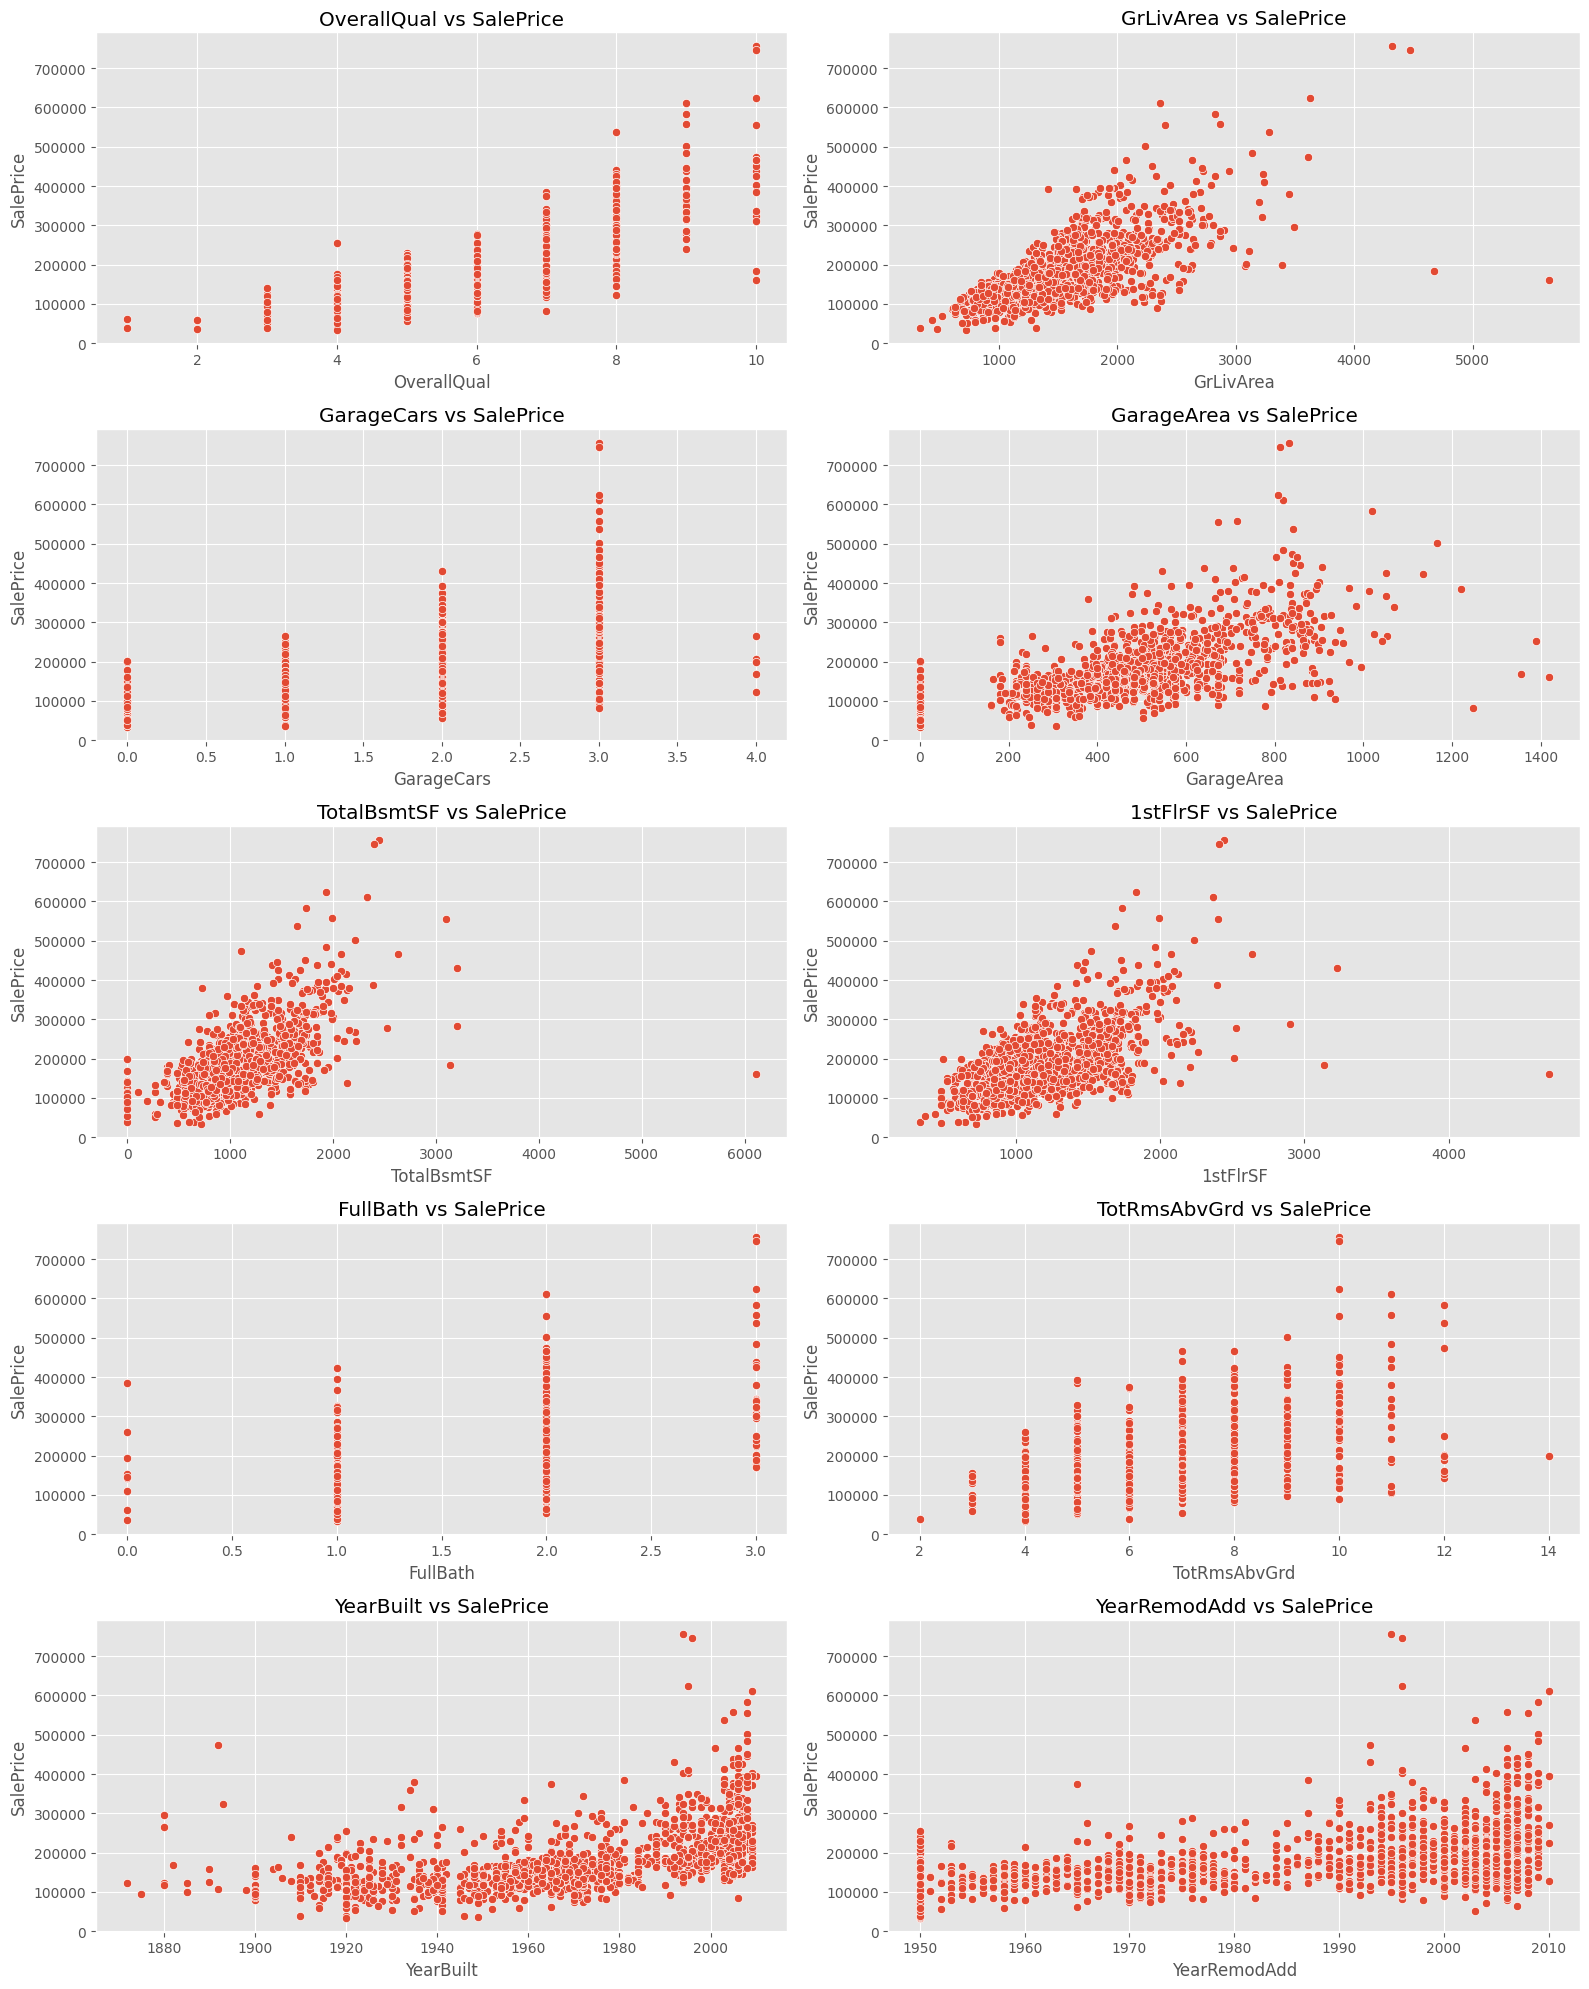

In [10]:
plt.figure(figsize=(16,20))

for i, col in enumerate(top_corr.index):
    plt.subplot(5,2,i+1)
    sns.scatterplot(data=df, x=col, y="SalePrice")
    plt.title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

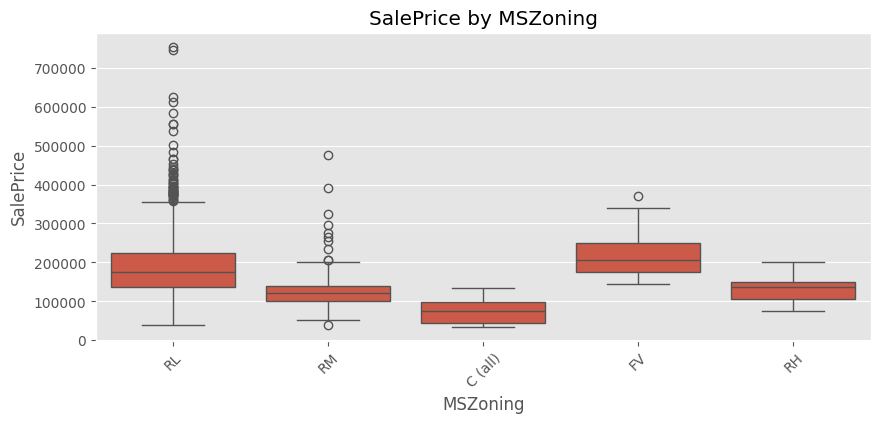

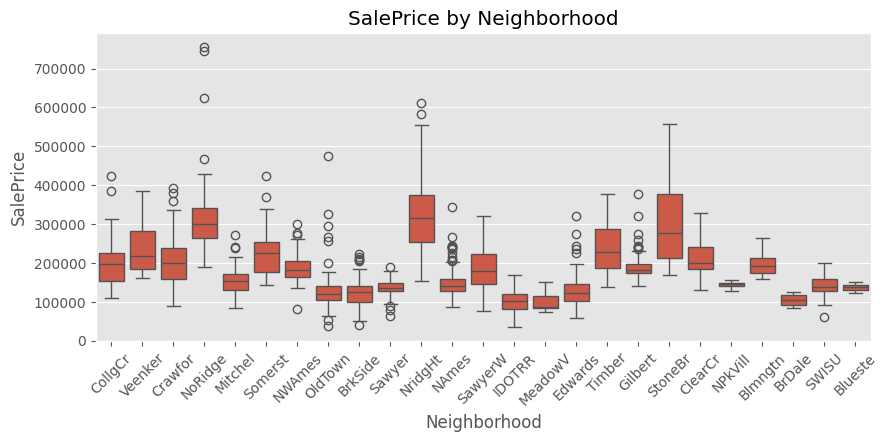

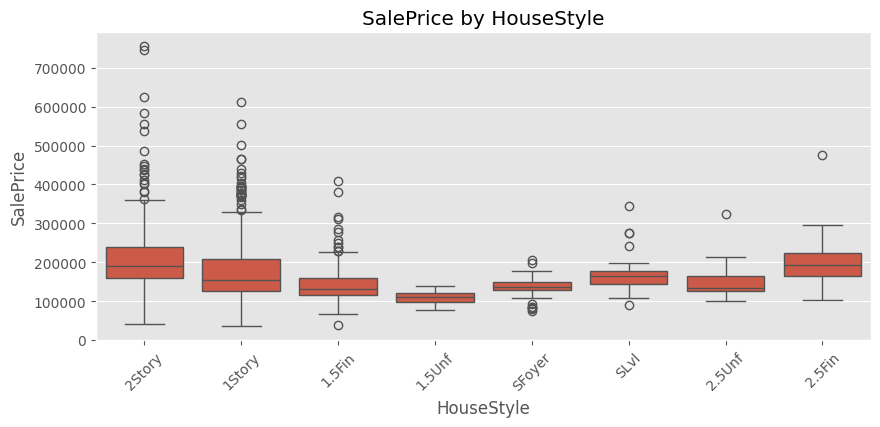

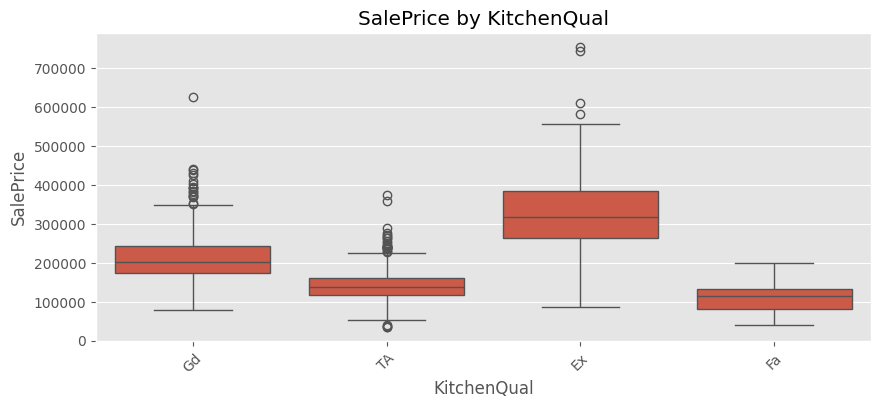

In [11]:
cat_features = ["MSZoning", "Neighborhood", "HouseStyle", "KitchenQual"]

for col in cat_features:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x=col, y="SalePrice")
    plt.xticks(rotation=45)
    plt.title(f"SalePrice by {col}")
    plt.show()

Key Insights:

1. OverallQual is the strongest predictor of house price.
2. Living area (GrLivArea) strongly correlates with price.
3. Garage and basement features significantly impact price.
4. Location (Neighborhood) introduces strong variance.
5. House quality dominates over pure size in some cases.

In [12]:
selected_features = {
    "numerical": [
        "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
        "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd",
        "YearBuilt", "YearRemodAdd"
    ],
    "categorical": [
        "MSZoning", "Neighborhood", "HouseStyle",
        "Exterior1st", "KitchenQual"
    ]
}

selected_features

{'numerical': ['OverallQual',
  'GrLivArea',
  'GarageCars',
  'GarageArea',
  'TotalBsmtSF',
  '1stFlrSF',
  'FullBath',
  'TotRmsAbvGrd',
  'YearBuilt',
  'YearRemodAdd'],
 'categorical': ['MSZoning',
  'Neighborhood',
  'HouseStyle',
  'Exterior1st',
  'KitchenQual']}